### Build A Basic Chatbot with LangGraph(GRAPH API)

In [20]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [21]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [22]:
import os
from dotenv import load_dotenv

load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: str | ForwardRef('os.PathLike[str]') | None = None, stream: IO[str] | None = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: str | None = 'utf-8') -> bool>

In [23]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [24]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1100aec10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1100af610>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### chatbot

In [25]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [26]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()

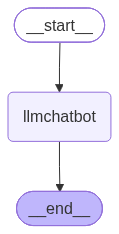

In [27]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
response = graph.invoke({"messages":"Hi"})

In [29]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='3c44cf6b-1bb7-4f23-94f0-0a7056295457'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.052788095, 'completion_tokens_details': None, 'prompt_time': 0.005462184, 'prompt_tokens_details': None, 'queue_time': 0.433532921, 'total_time': 0.058250279}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8358-e610-7e42-a7a3-22dd45141a2e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [30]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

### ChatBot with Tool

In [31]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [32]:
## Custom function
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

In [33]:
tools=[tool,multiply]

In [34]:
llm_with_tool = llm.bind_tools(tools)

In [35]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1100aec10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1100af610>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimiz

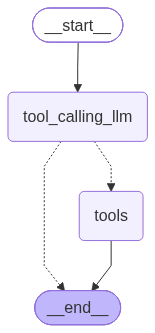

In [36]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

##compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
response=graph.invoke({"messages":"What is the recent AI news"})

In [39]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.latimes.com/business/story/2026-07-20/chinese-ai-model-rivals-chatgpt-jolting-silicon-valley", "title": "Chinese AI model rivals ChatGPT, jolting Silicon Valley - Los Angeles Times", "score": 0.65597594, "published_date": "Mon, 20 Jul 2026 17:42:21 GMT", "content": "Another powerful new artificial intelligence model from China took the U.S. tech industry by surprise Friday, the latest sign that Chinese startups that publicly release their “open-source” AI technology are making the California titans of AI sweat. The newest Kimi K3 model from Beijing-based startup Moonshot, run by a Pink Floyd-loving entrepreneur who earned his doctorate in Pittsburgh, appears to be catching up to the best versions of Anthropic’s Claude and OpenAI’s ChatGPT. “This may be the single biggest release of the year,” and marks a moment when open-source Chinese models are surpassing closed U.

In [41]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f6jbj9hb5)
 Call ID: f6jbj9hb5
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.latimes.com/business/story/2026-07-20/chinese-ai-model-rivals-chatgpt-jolting-silicon-valley", "title": "Chinese AI model rivals ChatGPT, jolting Silicon Valley - Los Angeles Times", "score": 0.65597594, "published_date": "Mon, 20 Jul 2026 17:42:21 GMT", "content": "Another powerful new artificial intelligence model from China took the U.S. tech industry by surprise Friday, the latest sign that Chinese startups that publicly release their “open-source” A